# CCMA to PhenPred preprocessing
This notebook inspects raw CCMA files in `PhenPred/data/CCMA/` and converts them to PhenPred-compatible layouts.

Planned outputs:
- `cas12.csv` -> `crisprcas9_ccma.csv` (samples x features, first column `ModelID`, top 500 most variable genes)
- `drug.csv` -> `drugresponse_ccma.csv` (features x samples, blank first header, top 500 most variable drugs)
- `rnaseq.csv` -> `transcriptomics_ccma.csv` (features x samples, blank first header)
- `ccma_promoter.csv` -> `methylation_ccma.csv` (features x samples)
- `epic.csv` -> `methylation_ccma.csv` (features x samples, optional fallback because it is very memory-heavy)
- `snv.csv` -> `mutations_summary_ccma.csv` (long format: `model_id`, `gene_symbol`, `cancer_driver`)

Note: CCMA sample IDs are 64-character hashes (not `SIDM`/`ACH-*`). Without an external mapping file, these cannot be aligned to the standard PhenPred samplesheet IDs.


In [1]:
from pathlib import Path
import csv
import warnings

import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/home/scai/scratch/PhenPredCCMA/")
CCMA_DIR = PROJECT_ROOT / 'data' / 'CCMA'
OUT_DIR = PROJECT_ROOT / 'data' / 'clines' / 'ccma_processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PROMOTER_METH_PATH = CCMA_DIR / 'ccma_promoter.csv'
PROCESS_PROMOTER = True

# Optional fallback: transpose ~1.07M EPIC probes if promoter methylation is unavailable.
PROCESS_EPIC = False

# Optional pilot mode for epic transpose; leave None to process full file when PROCESS_EPIC=True.
EPIC_MAX_FEATURES = None

TOP_CRISPR_FEATURES = 500
TOP_DRUG_FEATURES = 500

# Use the DepMap transcriptomics feature index as the RNA keep-list.
TRANSCRIPTOMICS_REFERENCE_PATH = (
    PROJECT_ROOT / 'data' / 'clines' / 'depmap23Q2' / 'OmicsExpressionGenesExpectedCountProfileVoom.csv'
)
FILTER_TRANSCRIPTOMICS_TO_REFERENCE = True

print(f'CCMA_DIR={CCMA_DIR}')
print(f'OUT_DIR={OUT_DIR}')
print(f'PROMOTER_METH_PATH={PROMOTER_METH_PATH}')
print(f'TOP_CRISPR_FEATURES={TOP_CRISPR_FEATURES}')
print(f'TOP_DRUG_FEATURES={TOP_DRUG_FEATURES}')
print(f'TRANSCRIPTOMICS_REFERENCE_PATH={TRANSCRIPTOMICS_REFERENCE_PATH}')
print(f'FILTER_TRANSCRIPTOMICS_TO_REFERENCE={FILTER_TRANSCRIPTOMICS_TO_REFERENCE}')


CCMA_DIR=/home/scai/scratch/PhenPredCCMA/data/CCMA
OUT_DIR=/home/scai/scratch/PhenPredCCMA/data/clines/ccma_processed
PROMOTER_METH_PATH=/home/scai/scratch/PhenPredCCMA/data/CCMA/ccma_promoter.csv
TOP_CRISPR_FEATURES=500
TOP_DRUG_FEATURES=500
TRANSCRIPTOMICS_REFERENCE_PATH=/home/scai/scratch/PhenPredCCMA/data/clines/depmap23Q2/OmicsExpressionGenesExpectedCountProfileVoom.csv
FILTER_TRANSCRIPTOMICS_TO_REFERENCE=True


In [2]:
def quick_csv_schema(path, preview_cols=6):
    with open(path, newline='') as fh:
        reader = csv.reader(fh)
        header = next(reader)
        n_rows = sum(1 for _ in reader)
    return {
        'file': path.name,
        'rows_without_header': n_rows,
        'n_cols': len(header),
        'first_col_name': header[0],
        'header_preview': header[:preview_cols],
    }

files = ['cas12.csv', 'drug.csv', 'rnaseq.csv', 'epic.csv', 'snv.csv']
schema = [quick_csv_schema(CCMA_DIR / f) for f in files]
if PROMOTER_METH_PATH.exists():
    schema.append(quick_csv_schema(PROMOTER_METH_PATH))
pd.DataFrame(schema)


,file,rows_without_header,n_cols,first_col_name,header_preview
0,cas12.csv,164,19842,ID,"[ID, CBSL, CH507-42P11.6, CNPY3-GNMT, ENSG0000..."
1,drug.csv,268,728,ID,"[ID, Puromycin_drug, ABT_737_drug, YM201636_dr..."
2,rnaseq.csv,385,63242,ID,"[ID, ENSG00000000003__TSPAN6, ENSG00000000005_..."
3,epic.csv,320,1074776,ID,"[ID, cg00000029, cg00000103, cg00000109, cg000..."
4,snv.csv,313,753,ID,"[ID, WARS2_snv, NEK1_snv, PRKDC_snv, KLHL6_snv..."
5,ccma_promoter.csv,353,12147,ID,"[ID, A1BG, A4GALT, AAAS, AACS, AADAT]"


In [3]:
# Cross-file sample ID overlap check
id_sets = {}
for f in files:
    p = CCMA_DIR / f
    with open(p, newline='') as fh:
        r = csv.reader(fh)
        next(r)
        ids = [row[0] for row in r]
    id_sets[f] = set(ids)
    sidm = sum(1 for x in ids if x.startswith('SIDM'))
    ach = sum(1 for x in ids if x.startswith('ACH-'))
    print(f"{f}: n={len(ids)} unique={len(set(ids))} SIDM={sidm} ACH={ach} example={ids[0][:20]}...")

print("\nPairwise overlaps")
for i, a in enumerate(files):
    for b in files[i + 1 :]:
        print(f"{a} vs {b}: {len(id_sets[a] & id_sets[b])}")

shared_all = set.intersection(*[id_sets[f] for f in files])
print(f"\nIDs shared by all {len(files)} files: {len(shared_all)}")


cas12.csv: n=164 unique=164 SIDM=0 ACH=0 example=272349fc0097407ed37e...
drug.csv: n=268 unique=268 SIDM=0 ACH=0 example=f53ab9414d8350cc4ccb...
rnaseq.csv: n=385 unique=385 SIDM=0 ACH=0 example=8ecfbe46735df2391a19...
epic.csv: n=320 unique=320 SIDM=0 ACH=0 example=8ecfbe46735df2391a19...
snv.csv: n=313 unique=313 SIDM=0 ACH=0 example=29596e5c9b6bbb31531f...

Pairwise overlaps
cas12.csv vs drug.csv: 141
cas12.csv vs rnaseq.csv: 147
cas12.csv vs epic.csv: 138
cas12.csv vs snv.csv: 125
drug.csv vs rnaseq.csv: 247
drug.csv vs epic.csv: 238
drug.csv vs snv.csv: 227
rnaseq.csv vs epic.csv: 304
rnaseq.csv vs snv.csv: 295
epic.csv vs snv.csv: 295

IDs shared by all 5 files: 119


In [4]:
def normalize_feature_name(name, strip_snv_suffix=False):
    x = str(name).strip()

    # CCMA uses ENSGxxxx__SYMBOL in rnaseq/cas12.
    if '__' in x:
        x = x.split('__', 1)[1]

    if strip_snv_suffix and x.endswith('_snv'):
        x = x[: -len('_snv')]

    return x


def normalize_drug_name(name):
    x = str(name).strip()

    if x.endswith('_drug'):
        x = x[: -len('_drug')]

    while x.endswith('_'):
        x = x[:-1]

    return x


def dedupe_columns_by_mean(df):
    # Collapse duplicate feature names after normalization.
    return df.T.groupby(level=0).mean().T


def dedupe_index_by_mean(df):
    return df.groupby(level=0).mean()


def select_top_variable_features(df, top_n):
    feature_var = df.var(axis=0).dropna().sort_values(ascending=False)
    if feature_var.empty:
        raise ValueError('No features with non-null variance were available for selection.')

    selected_features = feature_var.head(min(top_n, len(feature_var))).index.tolist()
    return df.loc[:, selected_features], feature_var


def load_reference_feature_set(path):
    reference_df = pd.read_csv(path, usecols=[0])
    feature_col = reference_df.columns[0]
    reference_features = pd.Index(reference_df[feature_col].astype(str).str.strip())
    reference_features = reference_features[reference_features != '']
    return pd.Index(reference_features.unique())


In [5]:
# 1) cas12 -> PhenPred-like crisprcas9 matrix (samples x features, top-variable subset)
cas12_raw = pd.read_csv(CCMA_DIR / 'cas12.csv', low_memory=False)
cas12 = cas12_raw.rename(columns={cas12_raw.columns[0]: 'ModelID'}).set_index('ModelID')
cas12 = cas12.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')
cas12.columns = [normalize_feature_name(c) for c in cas12.columns]
cas12 = dedupe_columns_by_mean(cas12)
cas12, cas12_var = select_top_variable_features(cas12, TOP_CRISPR_FEATURES)

cas12_out = OUT_DIR / 'crisprcas9_ccma.csv'
cas12.to_csv(cas12_out, index=True, index_label='ModelID')

print('cas12_out:', cas12_out)
print('shape:', cas12.shape)
print('selected genes:', len(cas12.columns))
print('top 10 genes by variance:', cas12_var.head(10).index.tolist())


cas12_out: /home/scai/scratch/PhenPredCCMA/data/clines/ccma_processed/crisprcas9_ccma.csv
shape: (164, 500)
selected genes: 500
top 10 genes by variance: ['CDK6', 'RAN', 'MED31', 'MAT2A', 'KIF18A', 'SCART1', 'XPO1', 'ELP2', 'CENPP', 'GMPS']


In [6]:
# 2) drug -> PhenPred-like drugresponse matrix (features x samples, top-variable subset)
drug_raw = pd.read_csv(CCMA_DIR / 'drug.csv', low_memory=False)
drug = drug_raw.rename(columns={drug_raw.columns[0]: 'ModelID'}).set_index('ModelID')
drug = drug.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')
drug.columns = [normalize_drug_name(c) for c in drug.columns]
drug = dedupe_columns_by_mean(drug)
drug, drug_var = select_top_variable_features(drug, TOP_DRUG_FEATURES)

drug_out = OUT_DIR / 'drugresponse_ccma.csv'
drug.T.to_csv(drug_out, index=True, index_label='')

print('drug_out:', drug_out)
print('shape:', drug.T.shape)
print('selected drugs:', len(drug.columns))
print('top 10 drugs by variance:', drug_var.head(10).index.tolist())


drug_out: /home/scai/scratch/PhenPredCCMA/data/clines/ccma_processed/drugresponse_ccma.csv
shape: (500, 268)
selected drugs: 500
top 10 drugs by variance: ['Terazosin_HCl', 'Kenpaullone', 'L_Thyroxine', 'Idebenone', 'ND646', 'Telatinib', 'Rucaparib_Phosphate__AG_014699__PF_01367338', 'RSL3', 'Ki8751', 'SR_4835']


In [7]:
cas12 = pd.read_csv(OUT_DIR / 'crisprcas9_ccma.csv', index_col=0)

In [8]:
cas12.iloc[:, :5].head()

,CDK6,RAN,MED31,MAT2A,KIF18A
ModelID,,,,,
272349fc0097407ed37ea7afd8fae76188f6f98ccce6971e1ec5694329a680fa,-3.516251,-4.498172,-1.419911,-3.830381,-0.957864
119f658903506c570633463bca21cb8cf4a686015cded71861d89ad79a280fa3,-1.659320,-4.346875,-4.152693,-0.634948,-0.889141
9ebf79c6c14a29bda6e51b76ece4803579e19c771698009426965fc0bfdad896,-0.649767,-4.287820,-3.695742,-1.159567,-4.022950
f927abad5a8c3ab2dd9a4a51ee64d53dfe1da0d0154b22017c14f16712154ee4,-1.827934,-1.586406,-3.298798,-1.465874,-2.008799
e94806f24c3bec94dca88562479e3fc98215e1225ca3b980057b49da4cf504e1,-1.770098,-3.871462,-3.989204,-2.909929,-0.448842


In [9]:
# 3) rnaseq -> PhenPred-like transcriptomics matrix (features x samples)
rna_raw = pd.read_csv(CCMA_DIR / 'rnaseq.csv', low_memory=False)
rna = rna_raw.rename(columns={rna_raw.columns[0]: 'ID'}).set_index('ID')
rna = rna.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')
rna.columns = [normalize_feature_name(c) for c in rna.columns]
rna = dedupe_columns_by_mean(rna)

reference_genes = None
if FILTER_TRANSCRIPTOMICS_TO_REFERENCE:
    reference_genes = load_reference_feature_set(TRANSCRIPTOMICS_REFERENCE_PATH)
    keep_genes = reference_genes[reference_genes.isin(rna.columns)]
    if keep_genes.empty:
        raise ValueError(
            f'No overlapping transcriptomics genes found in {TRANSCRIPTOMICS_REFERENCE_PATH}'
        )
    rna = rna.loc[:, keep_genes]

# Transpose to match PhenPred transcriptomics file layout.
rna_t = rna.T

rna_out = OUT_DIR / 'transcriptomics_ccma.csv'
rna_t.to_csv(rna_out, index=True, index_label='')

print('rna_out:', rna_out)
print('raw gene columns:', rna_raw.shape[1] - 1)
if reference_genes is not None:
    print('reference genes loaded:', len(reference_genes))
    print('genes retained after reference filter:', len(rna_t.index))
print('shape:', rna_t.shape)
print('first 5 features:', rna_t.index[:5].tolist())


rna_out: /home/scai/scratch/PhenPredCCMA/data/clines/ccma_processed/transcriptomics_ccma.csv
raw gene columns: 63241
reference genes loaded: 15278
genes retained after reference filter: 15141
shape: (15141, 385)
first 5 features: ['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT']


In [10]:
# 4) snv -> mutation outputs
snv_raw = pd.read_csv(CCMA_DIR / 'snv.csv', low_memory=False)
snv = snv_raw.rename(columns={snv_raw.columns[0]: 'ID'}).set_index('ID')
snv = snv.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce').fillna(0)
snv.columns = [normalize_feature_name(c, strip_snv_suffix=True) for c in snv.columns]

# Keep max across duplicate symbols (binary matrix semantics).
snv = snv.T.groupby(level=0).max().T
snv_bin = (snv > 0).astype(np.int8)

# 4a) Binary matrix (features x samples)
snv_matrix_out = OUT_DIR / 'mutations_binary_ccma.csv'
snv_bin.T.to_csv(snv_matrix_out, index=True, index_label='gene_symbol')

# 4b) Long format compatible with PhenPred mutation label import pattern
mut_long = snv_bin.stack().rename('value').reset_index()
mut_long.columns = ['model_id', 'gene_symbol', 'value']
mut_long = mut_long[mut_long['value'] > 0].drop(columns=['value'])
mut_long['cancer_driver'] = True
mut_long['source'] = 'CCMA_snv'

mut_long_out = OUT_DIR / 'mutations_summary_ccma.csv'
mut_long.to_csv(mut_long_out, index=False)

print('snv_matrix_out:', snv_matrix_out, 'shape=', snv_bin.T.shape)
print('mut_long_out:', mut_long_out, 'rows=', len(mut_long))
print(mut_long.head())


snv_matrix_out: /home/scai/scratch/PhenPredCCMA/data/clines/ccma_processed/mutations_binary_ccma.csv shape= (752, 313)
mut_long_out: /home/scai/scratch/PhenPredCCMA/data/clines/ccma_processed/mutations_summary_ccma.csv rows= 2081
                                               model_id gene_symbol  \
437   29596e5c9b6bbb31531f392a4f7e7c43108d27ca5e6bb8...        NEK1   
519   29596e5c9b6bbb31531f392a4f7e7c43108d27ca5e6bb8...       PRKDC   
731   29596e5c9b6bbb31531f392a4f7e7c43108d27ca5e6bb8...       WARS2   
1105  6724a2a2d31860943f7685f2a8a94ccd1e6177624a6f5a...       KLHL6   
1548  9c2d36e54fc6ef63145973506e99e84162a3f48d863442...  AP002748_5   

      cancer_driver    source  
437            True  CCMA_snv  
519            True  CCMA_snv  
731            True  CCMA_snv  
1105           True  CCMA_snv  
1548           True  CCMA_snv  


In [11]:
# 5) methylation -> PhenPred-like methylation matrix (features x samples)
# Prefer promoter methylation (gene-level); optionally fall back to EPIC probes.

methyl_out = OUT_DIR / 'methylation_ccma.csv'
methyl_written = False

if PROCESS_PROMOTER and PROMOTER_METH_PATH.exists():
    meth_raw = pd.read_csv(PROMOTER_METH_PATH, low_memory=False)
    meth = meth_raw.rename(columns={meth_raw.columns[0]: 'ID'}).set_index('ID')
    meth = meth.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')

    meth_t = meth.T
    meth_t.index = [normalize_feature_name(x) for x in meth_t.index]
    meth_t = dedupe_index_by_mean(meth_t)
    meth_t.to_csv(methyl_out, index=True, index_label='')
    methyl_written = True

    print('methylation source:', PROMOTER_METH_PATH)
    print('methyl_out:', methyl_out)
    print('shape:', meth_t.shape)
elif PROCESS_EPIC:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        epic_raw = pd.read_csv(CCMA_DIR / 'epic.csv', low_memory=False)

    epic = epic_raw.rename(columns={epic_raw.columns[0]: 'ID'}).set_index('ID')
    if EPIC_MAX_FEATURES is not None:
        epic = epic.iloc[:, :EPIC_MAX_FEATURES]

    epic = epic.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')
    epic_t = epic.T
    epic_t.to_csv(methyl_out, index=True, index_label='')
    methyl_written = True

    print('methylation source:', CCMA_DIR / 'epic.csv')
    print('methyl_out:', methyl_out)
    print('shape:', epic_t.shape)
else:
    print('Skipped methylation. Set PROCESS_PROMOTER=True or PROCESS_EPIC=True to generate methylation_ccma.csv')


methylation source: /home/scai/scratch/PhenPredCCMA/data/CCMA/ccma_promoter.csv
methyl_out: /home/scai/scratch/PhenPredCCMA/data/clines/ccma_processed/methylation_ccma.csv
shape: (12146, 353)


In [12]:
# 6) Minimal compatibility check + dataset dictionary snippet

def header_preview(path, n=6):
    with open(path, newline='') as fh:
        r = csv.reader(fh)
        h = next(r)
    return h[:n]

print('crispr header preview:', header_preview(cas12_out))
print('drug header preview:', header_preview(drug_out))
print('rna header preview:', header_preview(rna_out))
print('snv long columns:', pd.read_csv(mut_long_out, nrows=0).columns.tolist())
if 'methyl_written' in globals() and methyl_written:
    print('methylation header preview:', header_preview(methyl_out))

ccma_datasets_for_hypers = {
    'crisprcas9': str(cas12_out),
    'drugresponse': str(drug_out),
    'transcriptomics': str(rna_out),
}
if 'methyl_written' in globals() and methyl_written:
    ccma_datasets_for_hypers['methylation'] = str(methyl_out)

print("\nUse this in a Hyperparameters config (paths are absolute):")
print(ccma_datasets_for_hypers)

print(
    "\nTransfer toggle: set align_to_reference_features=True to restrict CCMA features to the "
    "DepMap-overlapping reference set, or False to use all CCMA features."
)
print("\nReminder: sample IDs are hashed. Provide a mapping file if you need SIDM/ACH alignment.")


crispr header preview: ['ModelID', 'CDK6', 'RAN', 'MED31', 'MAT2A', 'KIF18A']
drug header preview: ['', 'f53ab9414d8350cc4ccb523d79414340ce77f15a9f8d2645129ada453a59e822', '925572bba429c8f99c0ca5c9ba758e500ec3200c93adfb834e520c43c28f646e', 'dfd2f19e32e29276af6db25f8bbef4297f4ff91baf103708a2c6ac69fef975e0', 'f4877c1de403e5e4e76a5330c55048116180021ab9fd8c5131ea32706969e5e5', '7a716a8bc6934b3adf4174915ab31e91cf07197978cbb4a89e4e62e76f53aa5b']
rna header preview: ['', '8ecfbe46735df2391a19031c368d286443c21e9b8477741dc077b14a741183a9', '1559530de7a3e7e7009f5ff96aab4ee4df63906c6d81cf06c02feca862804e3d', 'e30c24a9d8d43977ea1984f7210fcb132dc39c679923cc1d9181c61497ae39d3', '43818a7b5f28733abb282ddd4524b40dd5135a9d368a31975bf0bce40a23ffd2', '8ed4d089f5851bc98a830f1ca7e3a57998cb61e5ae43c9b41f2140b28feb3ef7']
snv long columns: ['model_id', 'gene_symbol', 'cancer_driver', 'source']
methylation header preview: ['', '8ecfbe46735df2391a19031c368d286443c21e9b8477741dc077b14a741183a9', 'be9aeb751f570b28

In [13]:
# 7) Deterministic 80/20 hold-out split + export split-specific datasets
from sklearn.model_selection import train_test_split

SPLIT_TRAIN_FRACTION = 0.8
SPLIT_RANDOM_STATE = 42

if not ('methyl_written' in globals() and methyl_written):
    raise ValueError('Hold-out split expects methylation_ccma.csv to be available.')

split_views = {
    'crisprcas9': (cas12_out, 'samp_x_feat'),
    'drugresponse': (drug_out, 'feat_x_samp'),
    'transcriptomics': (rna_out, 'feat_x_samp'),
    'methylation': (methyl_out, 'feat_x_samp'),
    'mutations': (snv_matrix_out, 'feat_x_samp'),
}


def ordered_sample_ids(path, layout):
    if layout == 'feat_x_samp':
        return pd.read_csv(path, index_col=0, nrows=0).columns.astype(str).tolist()
    return pd.read_csv(path, index_col=0, usecols=[0]).index.astype(str).tolist()


def slice_view_file(input_path, output_path, sample_ids, layout):
    df = pd.read_csv(input_path, index_col=0)
    if layout == 'feat_x_samp':
        sliced = df.loc[:, sample_ids]
        sliced.to_csv(output_path, index=True, index_label='')
    else:
        sliced = df.loc[sample_ids]
        sliced.to_csv(output_path, index=True, index_label='ModelID')
    return sliced.shape


def write_sample_list(path, sample_ids):
    with open(path, 'w') as fh:
        fh.write(''.join(sample_ids) + '')


def relative_to_clines(path):
    return str(path.relative_to(PROJECT_ROOT / 'data' / 'clines'))

sample_ids_by_view = {
    view_name: ordered_sample_ids(path, layout)
    for view_name, (path, layout) in split_views.items()
}
eligible_samples = sorted(
    set.intersection(*[set(sample_ids) for sample_ids in sample_ids_by_view.values()])
)
train_ids, test_ids = train_test_split(
    eligible_samples,
    train_size=SPLIT_TRAIN_FRACTION,
    random_state=SPLIT_RANDOM_STATE,
    shuffle=True,
)
train_ids = sorted(train_ids)
test_ids = sorted(test_ids)
train_id_set = set(train_ids)
test_id_set = set(test_ids)

assert train_id_set.isdisjoint(test_id_set)
assert train_id_set | test_id_set == set(eligible_samples)

eligible_ids_path = OUT_DIR / 'ccma_holdout_eligible_ids.txt'
train_ids_path = OUT_DIR / 'ccma_holdout_train_ids.txt'
test_ids_path = OUT_DIR / 'ccma_holdout_test_ids.txt'
split_assignments_path = OUT_DIR / 'ccma_holdout_split.csv'

write_sample_list(eligible_ids_path, eligible_samples)
write_sample_list(train_ids_path, train_ids)
write_sample_list(test_ids_path, test_ids)

split_assignments = pd.DataFrame(
    {
        'model_id': train_ids + test_ids,
        'split': ['train'] * len(train_ids) + ['test'] * len(test_ids),
    }
).sort_values(['split', 'model_id']).reset_index(drop=True)
split_assignments.to_csv(split_assignments_path, index=False)

export_summary = []
for view_name, (input_path, layout) in split_views.items():
    ordered_ids = sample_ids_by_view[view_name]
    overlap_train_path = OUT_DIR / f'{input_path.stem}_overlap_train.csv'
    overlap_test_path = OUT_DIR / f'{input_path.stem}_overlap_test.csv'
    mosa_train_path = OUT_DIR / f'{input_path.stem}_mosa_train.csv'
    mosa_test_path = OUT_DIR / f'{input_path.stem}_mosa_test.csv'

    overlap_train_shape = slice_view_file(input_path, overlap_train_path, train_ids, layout)
    overlap_test_shape = slice_view_file(input_path, overlap_test_path, test_ids, layout)

    mosa_train_ids = [sid for sid in ordered_ids if sid not in test_id_set]
    mosa_test_ids = [sid for sid in ordered_ids if sid in test_id_set]

    mosa_train_shape = slice_view_file(input_path, mosa_train_path, mosa_train_ids, layout)
    mosa_test_shape = slice_view_file(input_path, mosa_test_path, mosa_test_ids, layout)

    export_summary.append(
        {
            'view_name': view_name,
            'layout': layout,
            'eligible_samples': len(eligible_samples),
            'overlap_train_samples': len(train_ids),
            'overlap_test_samples': len(test_ids),
            'mosa_train_samples': len(mosa_train_ids),
            'mosa_test_samples': len(mosa_test_ids),
            'overlap_train_shape': overlap_train_shape,
            'overlap_test_shape': overlap_test_shape,
            'mosa_train_shape': mosa_train_shape,
            'mosa_test_shape': mosa_test_shape,
        }
    )

export_summary = pd.DataFrame(export_summary)
print(export_summary)
print(f'Eligible complete-case samples: {len(eligible_samples)}')
print(f'Train complete-case samples: {len(train_ids)}')
print(f'Test complete-case samples: {len(test_ids)}')
print('Eligible IDs manifest:', eligible_ids_path)
print('Train IDs manifest:', train_ids_path)
print('Test IDs manifest:', test_ids_path)
print('Split assignments:', split_assignments_path)

ccma_mosa_train_datasets_for_hypers = {
    'crisprcas9': relative_to_clines(OUT_DIR / 'crisprcas9_ccma_mosa_train.csv'),
    'drugresponse': relative_to_clines(OUT_DIR / 'drugresponse_ccma_mosa_train.csv'),
    'transcriptomics': relative_to_clines(OUT_DIR / 'transcriptomics_ccma_mosa_train.csv'),
    'methylation': relative_to_clines(OUT_DIR / 'methylation_ccma_mosa_train.csv'),
}
ccma_holdout_test_datasets_for_hypers = {
    'crisprcas9': relative_to_clines(OUT_DIR / 'crisprcas9_ccma_mosa_test.csv'),
    'drugresponse': relative_to_clines(OUT_DIR / 'drugresponse_ccma_mosa_test.csv'),
    'transcriptomics': relative_to_clines(OUT_DIR / 'transcriptomics_ccma_mosa_test.csv'),
    'methylation': relative_to_clines(OUT_DIR / 'methylation_ccma_mosa_test.csv'),
}

print('Scratch MOSA train datasets:')
print(ccma_mosa_train_datasets_for_hypers)
print('labels_mutations_file:', relative_to_clines(OUT_DIR / 'mutations_binary_ccma_mosa_train.csv'))

print('Held-out MOSA test datasets:')
print(ccma_holdout_test_datasets_for_hypers)
print('holdout_labels_mutations_file:', relative_to_clines(OUT_DIR / 'mutations_binary_ccma_mosa_test.csv'))

         view_name       layout  eligible_samples  overlap_train_samples  \
0       crisprcas9  samp_x_feat               119                     95   
1     drugresponse  feat_x_samp               119                     95   
2  transcriptomics  feat_x_samp               119                     95   
3      methylation  feat_x_samp               119                     95   
4        mutations  feat_x_samp               119                     95   

   overlap_test_samples  mosa_train_samples  mosa_test_samples  \
0                    24                 140                 24   
1                    24                 244                 24   
2                    24                 361                 24   
3                    24                 329                 24   
4                    24                 289                 24   

  overlap_train_shape overlap_test_shape mosa_train_shape mosa_test_shape  
0           (95, 500)          (24, 500)       (140, 500)       (24, 5

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Variance of processed CRISPR genes (top-500 subset) ─────────────────────
cas12 = pd.read_csv(OUT_DIR / 'crisprcas9_ccma.csv', index_col=0)

gene_var = cas12.var(axis=0).dropna().sort_values(ascending=False)
gene_var.name = 'variance'

print(f"Processed CRISPR genes: {len(gene_var)}")
print(f"\nTop 20 by variance:\n{gene_var.head(20).to_string()}")


Processed CRISPR genes: 500

Top 20 by variance:
CDK6        1.265260
RAN         1.087676
MED31       1.057427
MAT2A       1.024202
KIF18A      1.021946
SCART1      1.012091
XPO1        1.004168
ELP2        0.966121
CENPP       0.963337
GMPS        0.960835
COP1        0.951092
MED12       0.945440
PAFAH1B1    0.944417
YARS2       0.941539
RPL14       0.881661
RRM1        0.881558
SMC5        0.852420
FXN         0.849507
COPS5       0.838807
ANKLE2      0.838081


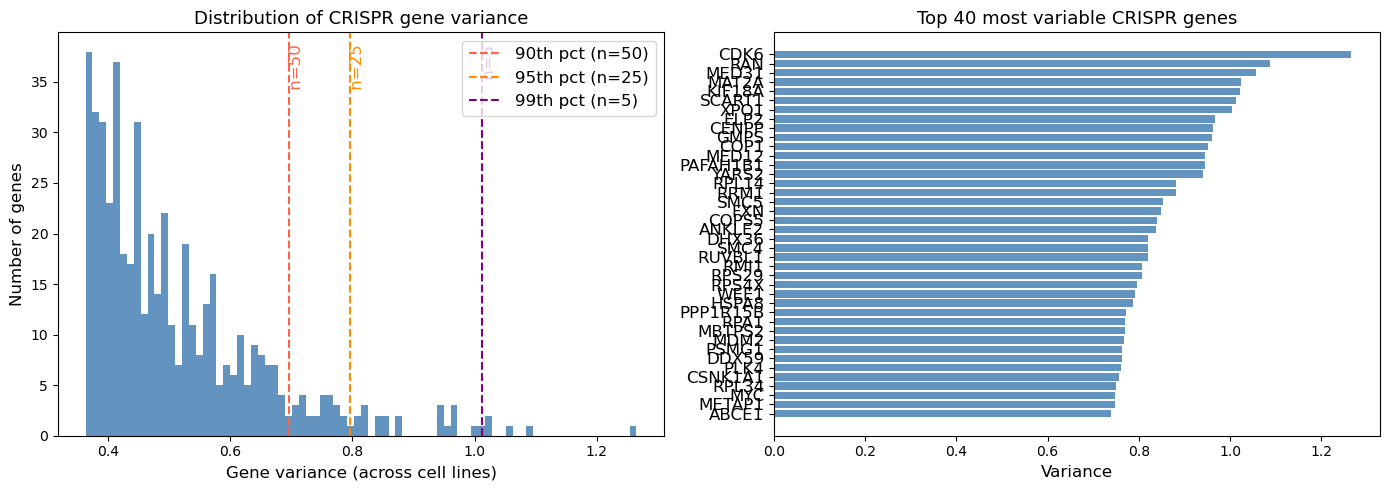

Figure saved.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram of per-gene variance ────────────────────────────────────
ax = axes[0]
ax.hist(gene_var.values, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('Gene variance (across cell lines)', fontsize=12)
ax.set_ylabel('Number of genes', fontsize=12)
ax.set_title('Distribution of CRISPR gene variance', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
pcts = [
    (0.90, 'tomato',     '90th pct'),
    (0.95, 'darkorange', '95th pct'),
    (0.99, 'purple',     '99th pct'),
]
ylim_top = ax.get_ylim()[1]
for q, color, label in pcts:
    thresh = gene_var.quantile(q)
    n_above = int((gene_var >= thresh).sum())
    ax.axvline(thresh, color=color, lw=1.5, ls='--', label=f'{label} (n={n_above:,})')
    ax.text(thresh, ylim_top * 0.97, f' n={n_above:,}', color=color,
            fontsize=12, va='top', ha='left', rotation=90)
ax.legend(fontsize=12)

# ── Right: top-N ranked bar chart ───────────────────────────────────────────
TOP_N_PLOT = 40
ax2 = axes[1]
top_plot = gene_var.head(TOP_N_PLOT)
bars = ax2.barh(top_plot.index[::-1], top_plot.values[::-1], color='steelblue', alpha=0.85)
ax2.set_xlabel('Variance', fontsize=12)
ax2.set_title(f'Top {TOP_N_PLOT} most variable CRISPR genes', fontsize=13)
ax2.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'vae' / 'crispr_gene_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [16]:
# ── Write top-N genes to shap_target_genes.txt ──────────────────────────────
# Processed CRISPR already contains the top-variable subset; this writes it out for SHAP.
TOP_N_GENES = min(TOP_CRISPR_FEATURES, len(gene_var))
SHAP_GENES_PATH = PROJECT_ROOT / 'reports' / 'vae' / 'files' / 'shap_target_genes.txt'

top_genes = gene_var.head(TOP_N_GENES).index.tolist()


In [17]:
"PIK3CA" in top_genes

True

In [18]:
with open(SHAP_GENES_PATH, 'w') as fh:
    fh.write('\n'.join(top_genes) + '\n')

print(f"Wrote {len(top_genes)} genes to {SHAP_GENES_PATH}")
print("Genes:", top_genes)


Wrote 500 genes to /home/scai/scratch/PhenPredCCMA/reports/vae/files/shap_target_genes.txt
Genes: ['CDK6', 'RAN', 'MED31', 'MAT2A', 'KIF18A', 'SCART1', 'XPO1', 'ELP2', 'CENPP', 'GMPS', 'COP1', 'MED12', 'PAFAH1B1', 'YARS2', 'RPL14', 'RRM1', 'SMC5', 'FXN', 'COPS5', 'ANKLE2', 'DHX36', 'SMC4', 'RUVBL1', 'RMI1', 'RPS29', 'RPS4X', 'WEE1', 'HSPA8', 'PPP1R15B', 'RPA1', 'MBTPS2', 'MDM2', 'PSMG1', 'DDX59', 'PLK4', 'CSNK1A1', 'RPL34', 'MYC', 'METAP1', 'ABCE1', 'COASY', 'SQLE', 'DCAF13', 'NCAPG', 'SHOC2', 'RBM39', 'CDK7', 'DHX15', 'BARD1', 'SKA2', 'ZBTB8OS', 'SMC3', 'EIF3M', 'IARS1', 'PRPF40A', 'EFTUD2', 'HIST1H3C', 'RPL32', 'RABGGTB', 'NCL', 'BCAS2', 'TRIM37', 'PFDN6', 'SF3A1', 'ATP6V1B2', 'RPS23', 'MDM4', 'RTTN', 'ACTL6A', 'FANCM', 'RPS8', 'POLR2B', 'EIF3I', 'SNRPG', 'CCND1', 'NGDN', 'CKAP5', 'ACTR10', 'SCFD1', 'PIK3CA', 'CPSF3', 'HAUS2', 'PRPF39', 'TRAPPC8', 'OIP5', 'YEATS4', 'GTF3A', 'CIAO1', 'XRN2', 'NAA15', 'DDX46', 'HNRNPK', 'H2BC21', 'NUTF2', 'RPLP0', 'THOC2', 'TWNK', 'KIF23', 'POLR3H', 'P

Total unique samples (union across all omics): 444
  Transcriptomics: N=385 measured, N=59 missing
  CRISPR-Cas12: N=164 measured, N=280 missing
  Drug response: N=268 measured, N=176 missing
  Methylation: N=353 measured, N=91 missing
  Mutations (SNV): N=313 measured, N=131 missing


/tmp/ipykernel_4048556/1870373150.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


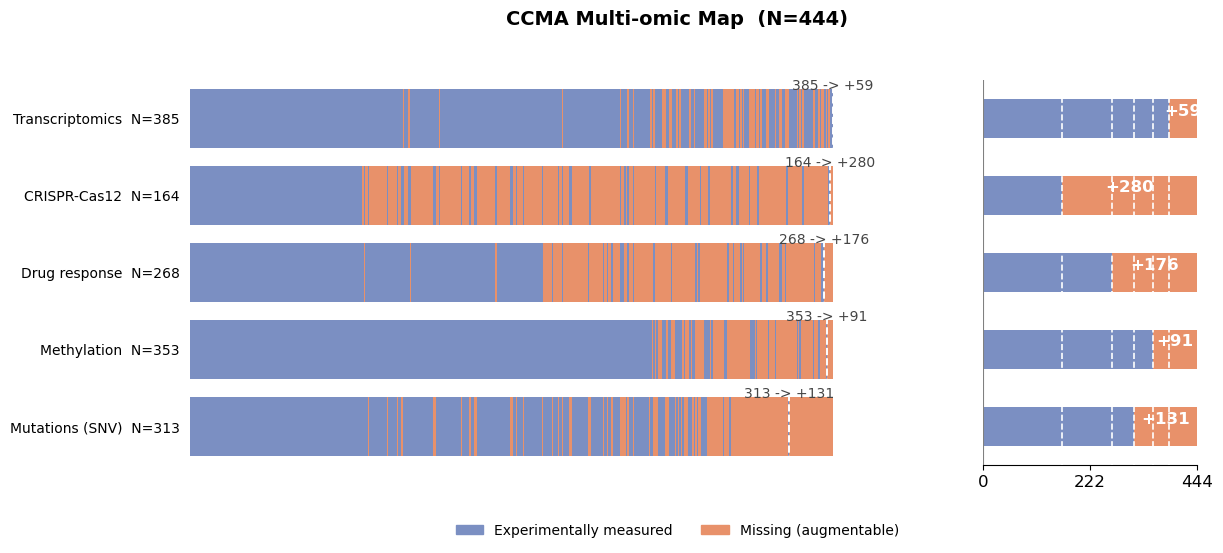

Figure saved to /home/scai/scratch/PhenPredCCMA/reports/vae/ccma_multiomic_map.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Collect sample ID sets per omic ─────────────────────────────────────────
omic_files = {
    'Transcriptomics': (OUT_DIR / 'transcriptomics_ccma.csv',  'feat_x_samp'),
    'CRISPR-Cas12':    (OUT_DIR / 'crisprcas9_ccma.csv',       'samp_x_feat'),
    'Drug response':   (OUT_DIR / 'drugresponse_ccma.csv',     'feat_x_samp'),
    'Methylation':     (OUT_DIR / 'methylation_ccma.csv',      'feat_x_samp'),
    'Mutations (SNV)': (OUT_DIR / 'mutations_binary_ccma.csv', 'feat_x_samp'),
}

omic_sample_ids = {}
for omic, (path, layout) in omic_files.items():
    if not path.exists():
        print(f"Skipping {omic}: file not found at {path}")
        continue
    if layout == 'feat_x_samp':
        df_head = pd.read_csv(path, index_col=0, nrows=0)
        omic_sample_ids[omic] = set(df_head.columns)
    else:  # samp_x_feat
        df_idx = pd.read_csv(path, index_col=0, usecols=[0])
        omic_sample_ids[omic] = set(df_idx.index)

all_samples = sorted(set.union(*omic_sample_ids.values()))
N_total = len(all_samples)
sample_idx = {s: i for i, s in enumerate(all_samples)}

print(f"Total unique samples (union across all omics): {N_total}")
for omic, ids in omic_sample_ids.items():
    print(f"  {omic}: N={len(ids)} measured, N={N_total - len(ids)} missing")

# ── Build binary presence matrix (omics x samples) ──────────────────────────
omic_names = list(omic_sample_ids.keys())
presence = np.zeros((len(omic_names), N_total), dtype=np.int8)
for i, omic in enumerate(omic_names):
    for sid in omic_sample_ids[omic]:
        presence[i, sample_idx[sid]] = 1

# Sort samples: most-complete first (desc total measured omics), then alphabetically
completeness = presence.sum(axis=0)
sort_order = np.argsort(-completeness, kind='stable')
presence_sorted = presence[:, sort_order]

# ── Omic labels with counts ──────────────────────────────────────────────────
n_measured = presence.sum(axis=1)
n_augment  = N_total - n_measured
omic_labels = [f"{o}  N={n:,}" for o, n in zip(omic_names, n_measured)]

# ── Colours ──────────────────────────────────────────────────────────────────
CLR_MEASURED = '#7B8FC2'   # muted blue (experimentally measured)
CLR_AUGMENT  = '#E8916A'   # muted orange (missing → augmentable)

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))
fig.patch.set_facecolor('white')

# Use gridspec: left panel wider, right panel narrower
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.35)
ax_rug  = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])

n_omics = len(omic_names)

# ── Left panel: per-sample rug / heatmap ─────────────────────────────────────
row_h   = 0.7   # height of each omic row
gap     = 0.2   # gap between rows
y_centers = [(n_omics - 1 - i) * (row_h + gap) for i in range(n_omics)]

for i in range(n_omics):
    row = presence_sorted[i]
    y0  = y_centers[i] - row_h / 2

    # Draw measured (blue) and missing (orange) rectangles per sample
    # For efficiency, draw one rectangle per contiguous run
    col_width = 1.0 / N_total
    for j, val in enumerate(row):
        color = CLR_MEASURED if val else CLR_AUGMENT
        ax_rug.add_patch(plt.Rectangle(
            (j / N_total, y0), col_width, row_h,
            color=color, linewidth=0
        ))

ax_rug.set_xlim(0, 1)
ax_rug.set_ylim(-row_h / 2 - gap / 2, y_centers[0] + row_h / 2 + gap / 2)
ax_rug.set_yticks(y_centers)
ax_rug.set_yticklabels(omic_labels, fontsize=10)
ax_rug.set_xticks([])
ax_rug.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax_rug.tick_params(left=False)

# ── Find per-omic boundary positions in the sorted sample space ──────────────
# boundary_x[i] = fraction along x-axis where the last measured sample for omic i falls
boundary_x = []
for i in range(n_omics):
    measured_positions = np.where(presence_sorted[i] == 1)[0]
    if len(measured_positions):
        last_measured = measured_positions.max()
        boundary_x.append((last_measured + 1) / N_total)
    else:
        boundary_x.append(0.0)

# ── Annotate rug: dashed vertical line + label at each omic's coverage boundary
for i in range(n_omics):
    bx = boundary_x[i]
    y0 = y_centers[i] - row_h / 2
    y1 = y_centers[i] + row_h / 2
    # Vertical dashed line spanning the row height
    ax_rug.plot([bx, bx], [y0 - gap * 0.4, y1 + gap * 0.4],
                color='white', lw=1.4, ls='--', zorder=5)
    # Count label above the line
    n_m = int(n_measured[i])
    n_a = int(n_augment[i])
    ax_rug.text(bx, y1 + gap * 0.55,
                f'{n_m:,} -> +{n_a:,}',
                ha='center', va='top', fontsize=10,
                color='#444444', zorder=6)

# ── Right panel: stacked horizontal bar chart ─────────────────────────────────
bar_h = 0.45
for i in range(n_omics):
    y = y_centers[i]
    ax_bar.barh(y, n_measured[i], height=bar_h, color=CLR_MEASURED, left=0)
    ax_bar.barh(y, n_augment[i],  height=bar_h, color=CLR_AUGMENT,  left=n_measured[i])

    # Vertical line at the junction between measured and augmentable
    ax_bar.axvline(n_measured[i], ymin=0, ymax=1,
                   color='white', lw=1.2, ls='--', zorder=5)

    # Annotate +N_augment gain to the right of the orange bar
    ax_bar.text(n_measured[i] + n_augment[i] / 2, y,
                f'+{int(n_augment[i]):,}',
                ha='center', va='bottom', fontsize=12,
                color='white', fontweight='bold', zorder=6)

ax_bar.set_xlim(0, N_total)
ax_bar.set_ylim(ax_rug.get_ylim())
ax_bar.set_yticks([])
ax_bar.axvline(0, color='grey', lw=0.8)
ax_bar.set_xticks([0, N_total // 2, N_total])
ax_bar.set_xticklabels(['0', str(N_total // 2), str(N_total)], fontsize=12)
ax_bar.spines[['top', 'right', 'left']].set_visible(False)
ax_bar.tick_params(bottom=True)

# ── Shared title and legend ───────────────────────────────────────────────────
fig.suptitle(
    f"CCMA Multi-omic Map  (N={N_total:,})",
    fontsize=14, fontweight='bold', y=1.02
)

legend_patches = [
    mpatches.Patch(color=CLR_MEASURED, label='Experimentally measured'),
    mpatches.Patch(color=CLR_AUGMENT,  label='Missing (augmentable)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.06), fontsize=10, frameon=False)

plt.tight_layout()
out_path = PROJECT_ROOT / 'reports' / 'vae' / 'ccma_multiomic_map.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {out_path}")
